In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import splu
from neuromodes.io import fetch_surf
from neuromodes.distances import geodesic_heat
from lapy import TriaMesh, Solver
from lapy.heat import diffusion
from lapy.diffgeo import tria_compute_geodesic_f

In [ ]:
n = np.random.randint(50, 150)  # Randomly choose n between 10 and 100
pos = np.random.randint(0, n * n)  # Randomly choose a vertex index as source
print(f"Square with {n} vertices per side, total vertices: {n*n}")
print(f"Source vertex index: {pos}")

## generate square mesh with z coordinates all zero
# generate vertices
x, y = np.meshgrid(np.arange(n), np.arange(n), indexing='xy')
x = x.flatten().astype(np.float64)
y = y.flatten().astype(np.float64)
mask = (x != 0) & (x != n - 1) & (y != 0) & (y != n - 1)
x[mask] += np.random.uniform(low=-0.4, high=0.4, size=mask.sum())
y[mask] += np.random.uniform(low=-0.4, high=0.4, size=mask.sum())
vertices = np.stack([x/(n-1),y/(n-1),np.zeros_like(x)], axis=1).astype(np.float64)

# procedurally generate faces for square mesh
vi = np.arange(n * n).reshape(n, n)
top_left = vi[:-1, :-1].flatten()
top_right = top_left + 1
bottom_left = top_left + n
bottom_right = top_left + n + 1
tri1 = np.stack([top_left, top_right, bottom_left], axis=1)
tri2 = np.stack([top_right, bottom_right, bottom_left], axis=1)
faces = np.vstack([tri1, tri2])

# set up TriaMesh and some key features
T = TriaMesh(vertices, faces)
fem = Solver(T, lump=True)
nv = T.v.shape[0] 


## compare geodesic distances from heat with euclidean distances
# lapy distances
dists_lapy = tria_compute_geodesic_f(T, diffusion(T, vids=pos) )

# geodesic distances from heat
splu_stiffness = splu(fem.stiffness)
m = 1
t = m * T.avg_edge_length() ** 2
hmat = fem.mass + t * fem.stiffness
splu_heat = splu(hmat)

dists_splu = np.squeeze(geodesic_heat(T, (pos,), splu_heat, splu_stiffness))

assert(np.allclose(dists_lapy, dists_splu))

## set up visualisations
s = 10 # size of scatter points


Square with 115 vertices per side, total vertices: 13225
Source vertex index: 12612


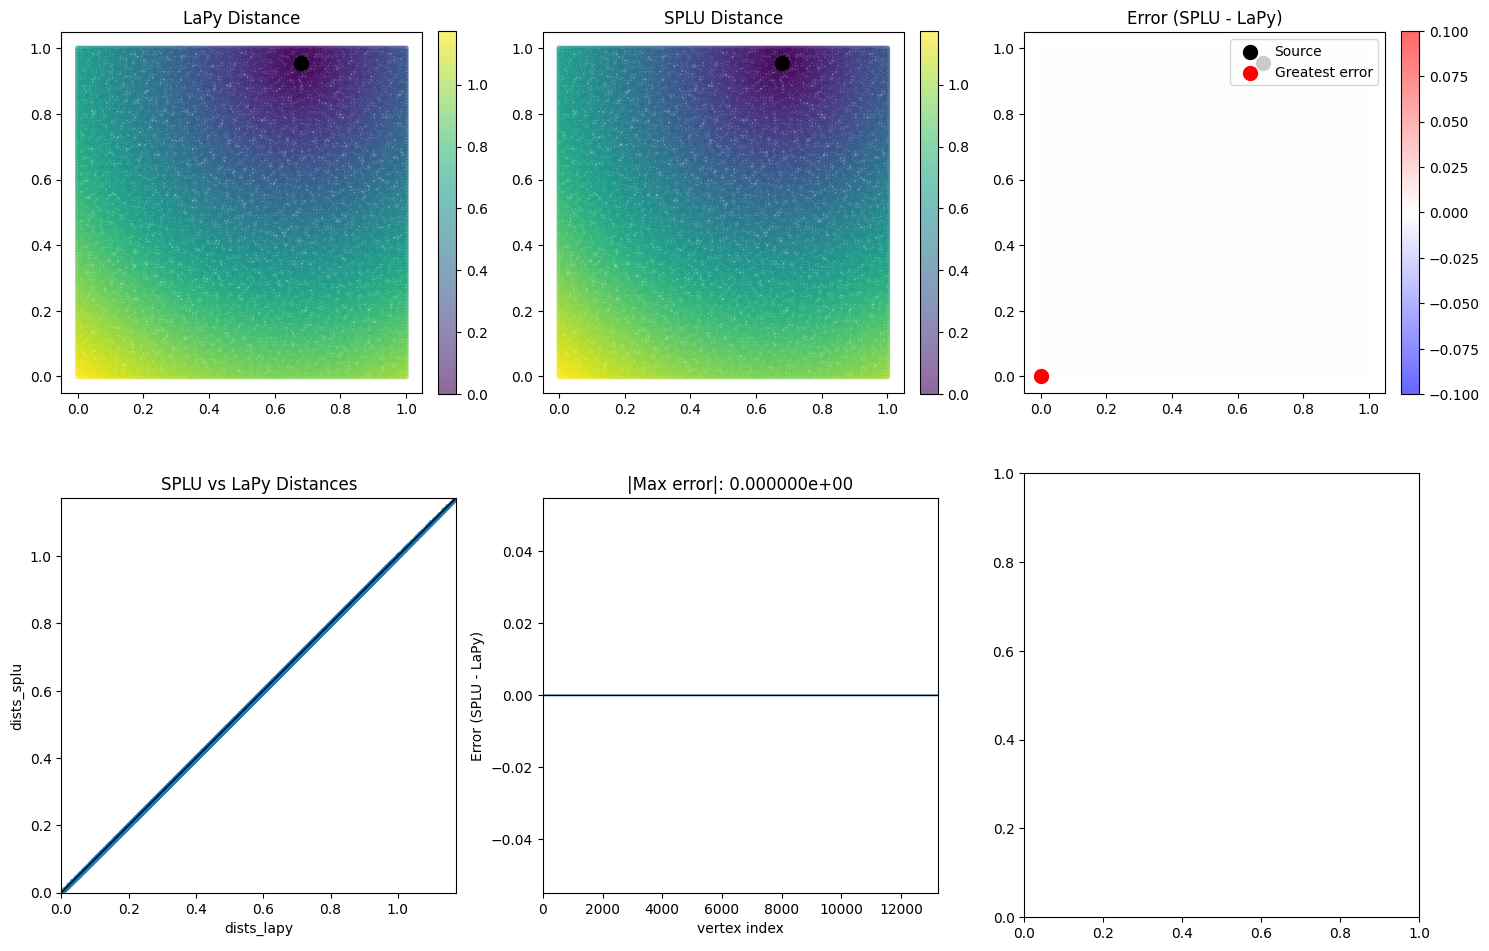

In [13]:
## Visualisations
dists_max = max(dists_splu.max(), dists_lapy.max())
dists_err = dists_splu - dists_lapy
max_err = np.max(np.abs(dists_splu - dists_lapy))
max_idx = np.argmax(np.abs(dists_splu - dists_lapy))

fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.flatten()

# plot vertices in 2D space
sc = axs[0].scatter(vertices[:, 0], vertices[:, 1], c=dists_lapy, cmap='viridis', s=s, alpha=0.6, vmin=0, vmax=dists_max)
axs[0].scatter(vertices[pos, 0], vertices[pos, 1], c='black', s=100, marker='o', label='Source')
axs[0].set_aspect('equal', 'box')
axs[0].set_title('LaPy Distance')
plt.colorbar(sc, ax=axs[0], orientation='vertical', pad=0.04, fraction=0.046)

sc = axs[1].scatter(vertices[:, 0], vertices[:, 1], c=dists_splu, cmap='viridis', s=s, alpha=0.6, vmin=0, vmax=dists_max)
axs[1].scatter(vertices[pos, 0], vertices[pos, 1], c='black', s=100, marker='o', label='Source')
axs[1].set_aspect('equal', 'box')
axs[1].set_title('SPLU Distance')
plt.colorbar(sc, ax=axs[1], orientation='vertical', pad=0.04, fraction=0.046)

sc = axs[2].scatter(vertices[:, 0], vertices[:, 1], c=dists_err, cmap='bwr', s=s, alpha=0.6, vmin=-max_err, vmax=max_err)
axs[2].scatter(vertices[pos, 0], vertices[pos, 1], c='black', s=100, marker='o', label='Source')
axs[2].scatter(vertices[max_idx, 0], vertices[max_idx, 1], c='red', s=100, marker='o', label='Greatest error')
axs[2].set_aspect('equal', 'box')
axs[2].set_title('Error (SPLU - LaPy)')
axs[2].legend()
plt.colorbar(sc, ax=axs[2], orientation='vertical', pad=0.04, fraction=0.046)

# scatter plot: dists_splu vs dists_lapy
axs[3].scatter(dists_lapy, dists_splu, s=6, alpha=0.7)
axs[3].plot([0, dists_max], [0, dists_max], color='k', lw=1)
axs[3].set_aspect('equal', 'box')
axs[3].set_xlim(0, dists_max)
axs[3].set_ylim(0, dists_max)
axs[3].set_xlabel('dists_lapy')
axs[3].set_ylabel('dists_splu')
axs[3].set_title('SPLU vs LaPy Distances')

# absolute difference plot over all vertices
axs[4].plot(np.arange(1,len(dists_splu)+1), dists_err[np.argsort(dists_lapy)], lw=0.8)
axs[4].plot([0, len(dists_splu)], [0, 0], color='k', lw=1)
axs[4].set_box_aspect(1)
axs[4].set_xlim(0, len(dists_splu))
axs[4].set_xlabel('vertex index')
axs[4].set_ylabel('Error (SPLU - LaPy)')
axs[4].set_title(f'|Max error|: {max_err:.6e}')

plt.tight_layout()
plt.show()


In [14]:
mesh, _ = fetch_surf(density='4k', hemi='L', surf_type='sphere')
mesh.vertices = mesh.vertices / np.linalg.norm(mesh.vertices, axis=1, keepdims=True)  # Scale vertices to unit sphere


T = TriaMesh(mesh.vertices, mesh.faces)
fem = Solver(T, lump=True)

## compare geodesic distances from heat with euclidean distances
pos = np.random.randint(0, T.v.shape[0])  # Randomly choose a vertex index as source
print(f"Source vertex index: {pos}")

# lapy distances
dists_lapy = tria_compute_geodesic_f(T, diffusion(T, vids=pos) )

# geodesic distances from heat
splu_stiffness = splu(fem.stiffness)
m = 1
t = m * T.avg_edge_length() ** 2
hmat = fem.mass + t * fem.stiffness
splu_heat = splu(hmat)
dists_splu = np.squeeze(geodesic_heat(T, (pos,), splu_heat, splu_stiffness))

## set up visualisations
s = (T.v[:,2]+1)*10+5
vertices = T.v
vertices[:, 0] -= 0.01 * vertices[:, 2]  # Shift x-coordinates based on z for better visibility
vertices[:, 1] -= 0.01 * vertices[:, 2]  # Shift y-coordinates based on z for better visibility


Source vertex index: 1343


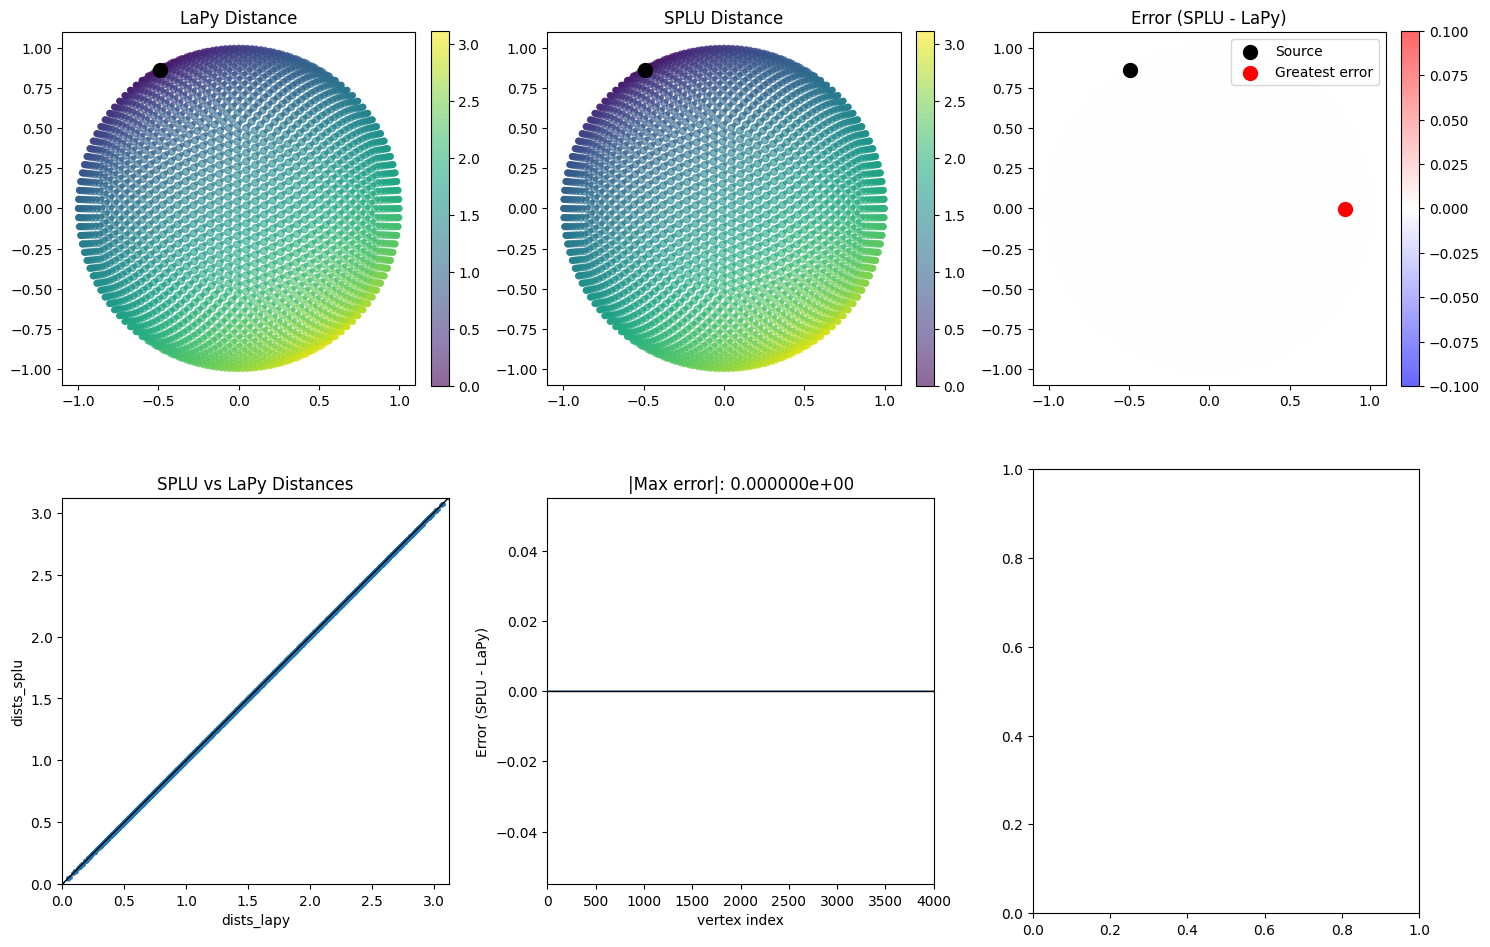

In [ ]:
## Visualisations
dists_max = max(dists_splu.max(), dists_lapy.max())
dists_err = dists_splu - dists_lapy
max_err = np.max(np.abs(dists_splu - dists_lapy))
max_idx = np.argmax(np.abs(dists_splu - dists_lapy))

fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.flatten()

# plot vertices in 2D space
sc = axs[0].scatter(vertices[:, 0], vertices[:, 1], c=dists_lapy, cmap='viridis', s=s, alpha=0.6, vmin=0, vmax=dists_max)
axs[0].scatter(vertices[pos, 0], vertices[pos, 1], c='black', s=100, marker='o', label='Source')
axs[0].set_aspect('equal', 'box')
axs[0].set_title('LaPy Distance')
plt.colorbar(sc, ax=axs[0], orientation='vertical', pad=0.04, fraction=0.046)

sc = axs[1].scatter(vertices[:, 0], vertices[:, 1], c=dists_splu, cmap='viridis', s=s, alpha=0.6, vmin=0, vmax=dists_max)
axs[1].scatter(vertices[pos, 0], vertices[pos, 1], c='black', s=100, marker='o', label='Source')
axs[1].set_aspect('equal', 'box')
axs[1].set_title('SPLU Distance')
plt.colorbar(sc, ax=axs[1], orientation='vertical', pad=0.04, fraction=0.046)

sc = axs[2].scatter(vertices[:, 0], vertices[:, 1], c=dists_err, cmap='bwr', s=s, alpha=0.6, vmin=-max_err, vmax=max_err)
axs[2].scatter(vertices[pos, 0], vertices[pos, 1], c='black', s=100, marker='o', label='Source')
axs[2].scatter(vertices[max_idx, 0], vertices[max_idx, 1], c='red', s=100, marker='o', label='Greatest error')
axs[2].set_aspect('equal', 'box')
axs[2].set_title('Error (SPLU - LaPy)')
axs[2].legend()
plt.colorbar(sc, ax=axs[2], orientation='vertical', pad=0.04, fraction=0.046)

# scatter plot: dists_splu vs dists_lapy
axs[3].scatter(dists_lapy, dists_splu, s=6, alpha=0.7)
axs[3].plot([0, dists_max], [0, dists_max], color='k', lw=1)
axs[3].set_aspect('equal', 'box')
axs[3].set_xlim(0, dists_max)
axs[3].set_ylim(0, dists_max)
axs[3].set_xlabel('dists_lapy')
axs[3].set_ylabel('dists_splu')
axs[3].set_title('SPLU vs LaPy Distances')

# absolute difference plot over all vertices
axs[4].plot(np.arange(1,len(dists_splu)+1), dists_err[np.argsort(dists_lapy)], lw=0.8)
axs[4].plot([0, len(dists_splu)], [0, 0], color='k', lw=1)
axs[4].set_box_aspect(1)
axs[4].set_xlim(0, len(dists_splu))
axs[4].set_xlabel('vertex index')
axs[4].set_ylabel('Error (SPLU - LaPy)')
axs[4].set_title(f'|Max error|: {max_err:.6e}')

assert(np.allclose(dists_lapy, dists_splu))

plt.tight_layout()
plt.show()
